In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

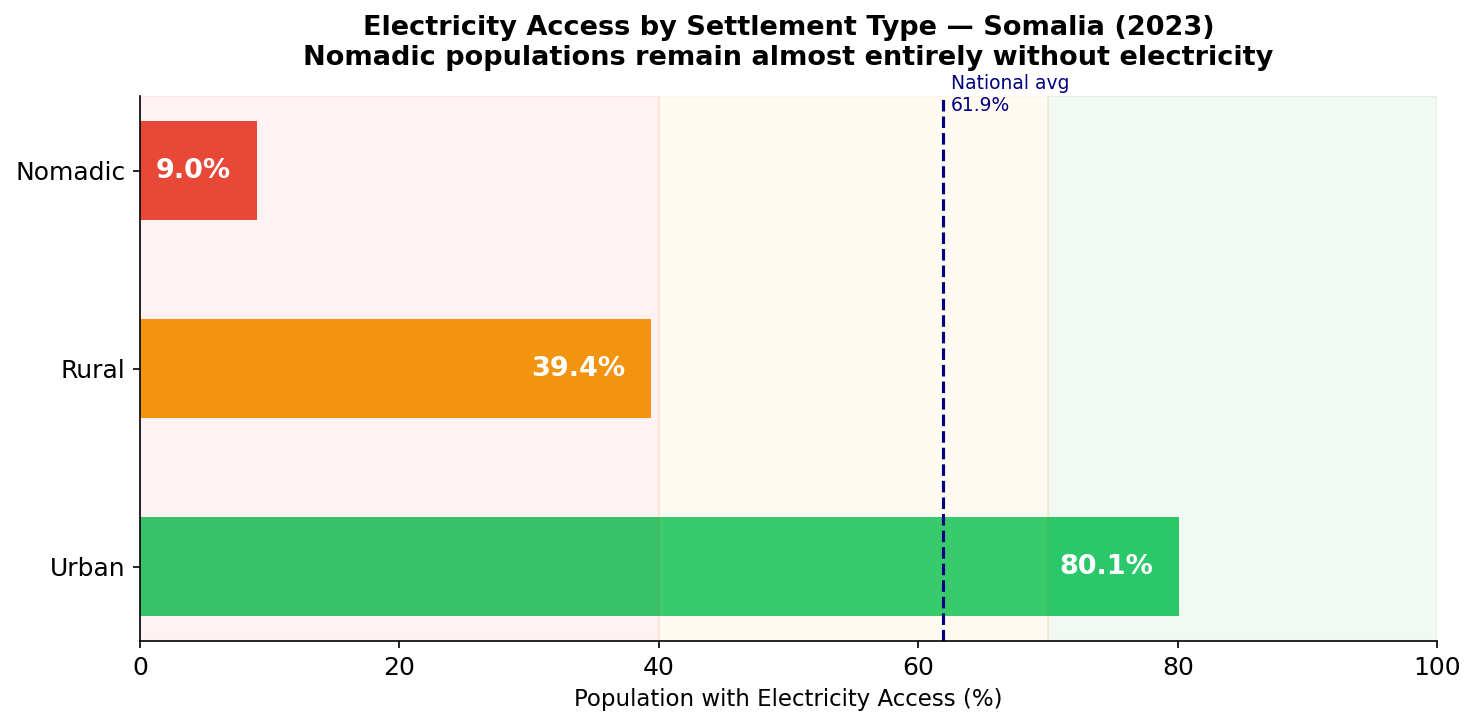

In [2]:
# Figure 1 — Electricity Access by Settlement Type

categories = ["Urban", "Rural", "Nomadic"]
values = [80.1, 39.4, 9.0]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(categories, values, color=colors, height=0.5)

# Add value labels inside bars
for bar, val in zip(bars, values):
    ax.text(bar.get_width() - 2, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", ha="right",
            fontsize=13, fontweight="bold", color="white")

# Add national average line
ax.axvline(x=61.9, color="navy", linestyle="--", linewidth=1.5)
ax.text(62.5, 2.3, "National avg\n61.9%", fontsize=9, color="navy")

ax.set_xlim(0, 100)
ax.set_xlabel("Population with Electricity Access (%)", fontsize=11)
ax.set_title("Electricity Access by Settlement Type — Somalia (2023)\n"
             "Nomadic populations remain almost entirely without electricity",
             fontsize=13, fontweight="bold", pad=15)

ax.axvspan(0, 40, alpha=0.05, color="red")
ax.axvspan(40, 70, alpha=0.05, color="orange")
ax.axvspan(70, 100, alpha=0.05, color="green")

plt.tight_layout()
plt.savefig("figure1_electricity_access.png", dpi=150, bbox_inches="tight")
plt.show()

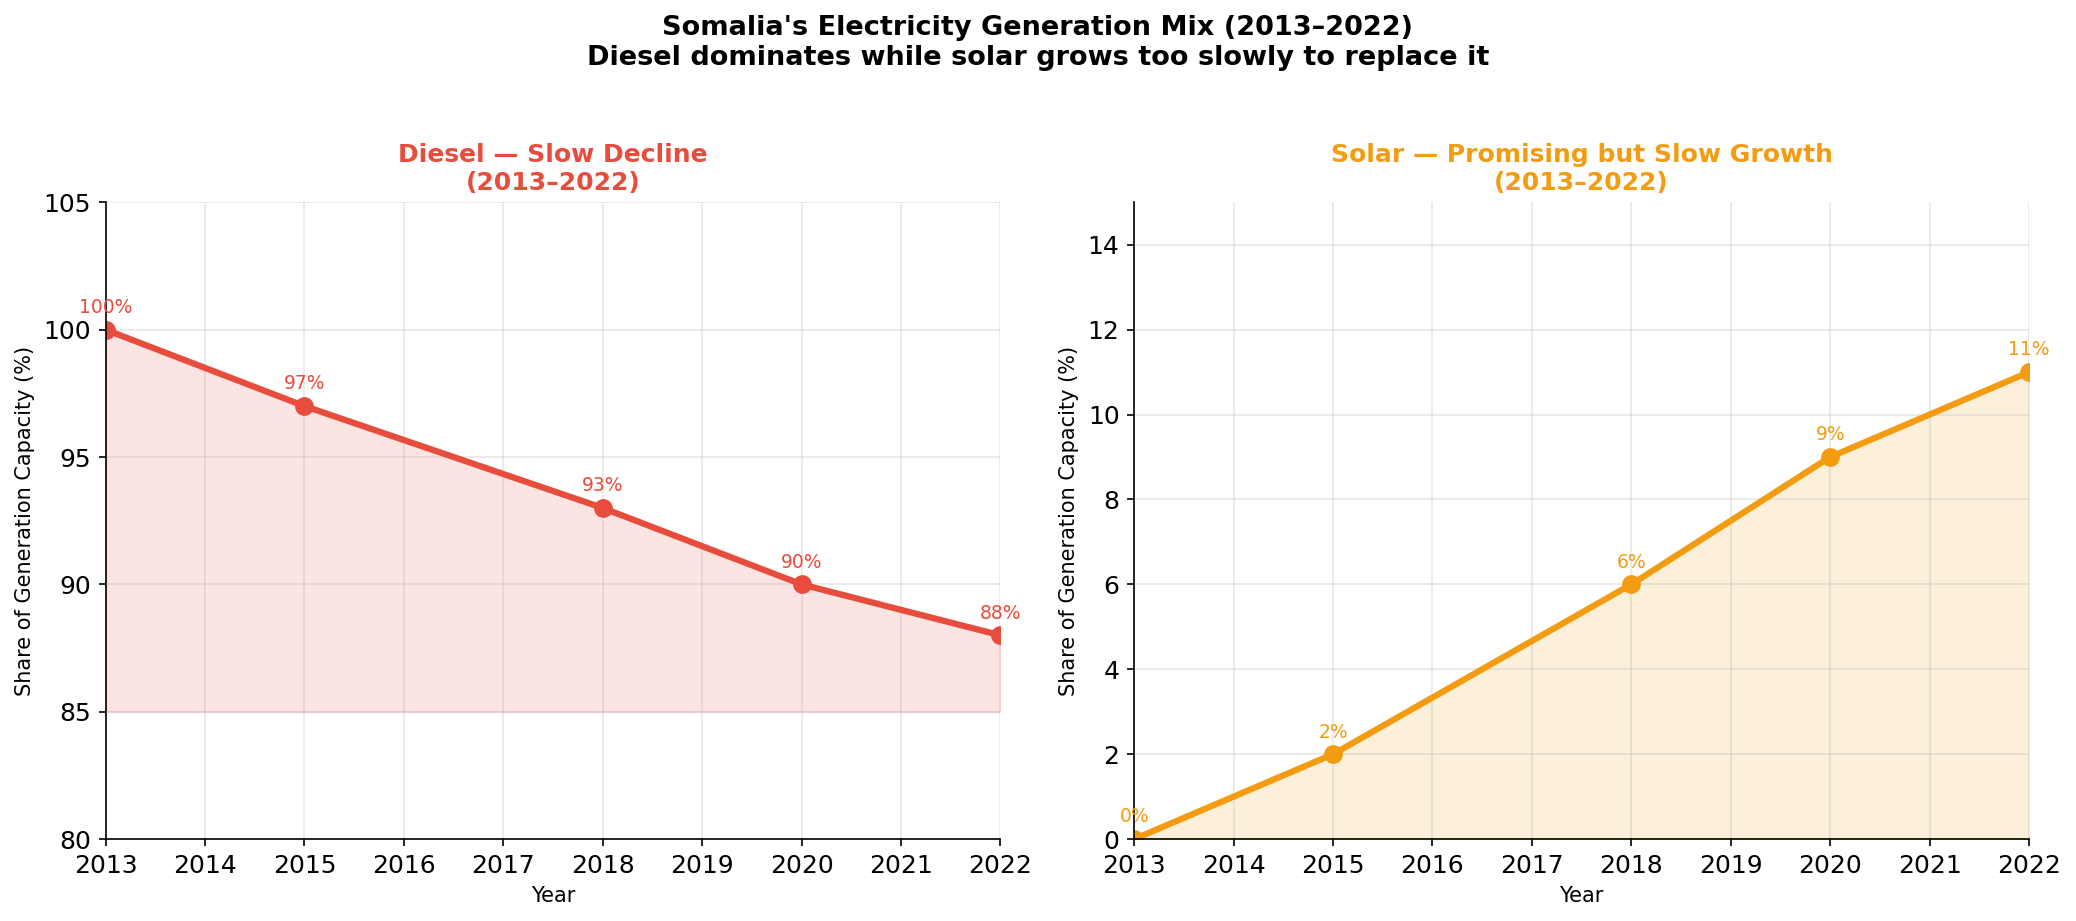

In [3]:
# Figure 2 — Diesel Decline and Solar Growth (Side by Side)

years  = [2013, 2015, 2018, 2020, 2022]
diesel = [100, 97, 93, 90, 88]
solar  = [0, 2, 6, 9, 11]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Chart: Diesel Decline ---
ax1.plot(years, diesel, color="#e74c3c", linewidth=3,
         marker="o", markersize=8)
ax1.fill_between(years, diesel, 85,
                 alpha=0.15, color="#e74c3c")
ax1.set_ylim(80, 105)
ax1.set_xlim(2013, 2022)
ax1.set_title("Diesel — Slow Decline\n(2013–2022)",
              fontsize=12, fontweight="bold", color="#e74c3c")
ax1.set_ylabel("Share of Generation Capacity (%)", fontsize=10)
ax1.set_xlabel("Year", fontsize=10)
ax1.grid(True, alpha=0.3)
for x, y in zip(years, diesel):
    ax1.annotate(f"{y}%", xy=(x, y),
                 xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=9, color="#e74c3c")

# --- Right Chart: Solar Growth ---
ax2.plot(years, solar, color="#f39c12", linewidth=3,
         marker="o", markersize=8)
ax2.fill_between(years, solar, 0,
                 alpha=0.15, color="#f39c12")
ax2.set_ylim(0, 15)
ax2.set_xlim(2013, 2022)
ax2.set_title("Solar — Promising but Slow Growth\n(2013–2022)",
              fontsize=12, fontweight="bold", color="#f39c12")
ax2.set_ylabel("Share of Generation Capacity (%)", fontsize=10)
ax2.set_xlabel("Year", fontsize=10)
ax2.grid(True, alpha=0.3)
for x, y in zip(years, solar):
    ax2.annotate(f"{y}%", xy=(x, y),
                 xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=9, color="#f39c12")

plt.suptitle("Somalia's Electricity Generation Mix (2013–2022)\n"
             "Diesel dominates while solar grows too slowly to replace it",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("figure2_generation_mix.jpg", dpi=300, bbox_inches="tight")
plt.show()

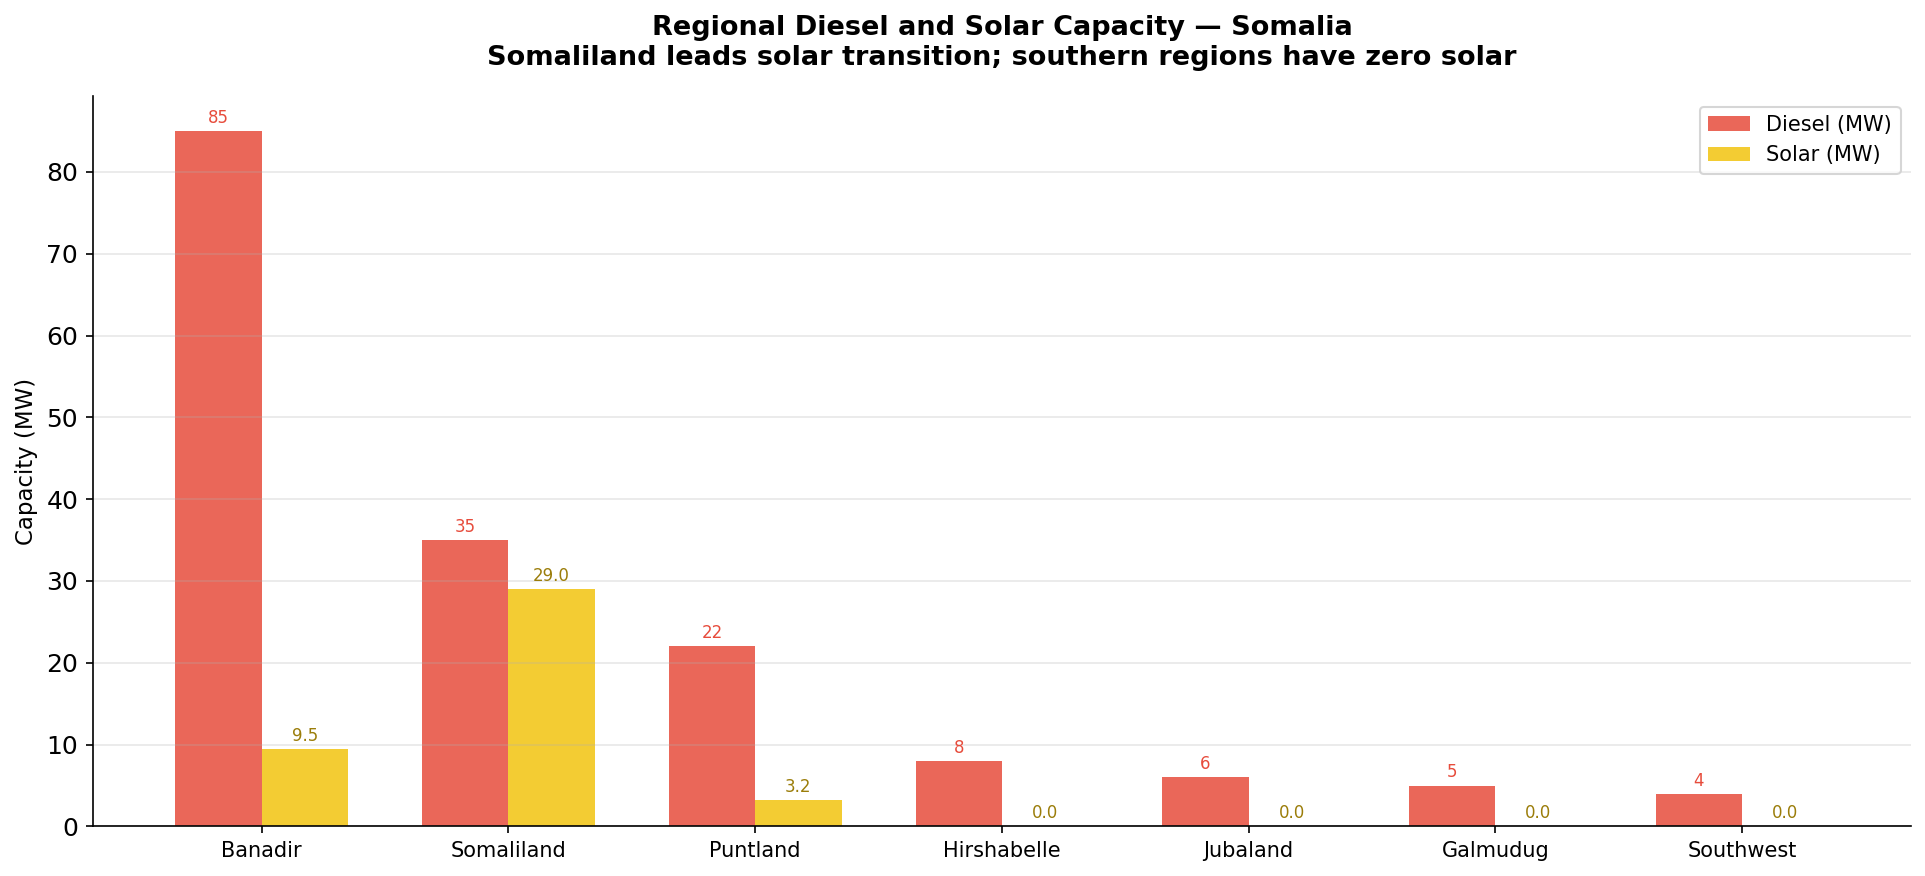

In [6]:
# Figure 3 — Regional Diesel and Solar Capacity

regions = ["Banadir", "Somaliland", "Puntland", 
           "Hirshabelle", "Jubaland", "Galmudug", "Southwest"]
diesel  = [85, 35, 22, 8, 6, 5, 4]
solar   = [9.5, 29, 3.2, 0, 0, 0, 0]

x = np.arange(len(regions))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, diesel, width,
               label="Diesel (MW)", color="#e74c3c", alpha=0.85)
bars2 = ax.bar(x + width/2, solar, width,
               label="Solar (MW)", color="#f1c40f", alpha=0.85)

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height()}", ha="center",
            va="bottom", fontsize=8, color="#e74c3c")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height()}", ha="center",
            va="bottom", fontsize=8, color="#9b7d0a")

ax.set_xticks(x)
ax.set_xticklabels(regions, rotation=0, ha="center", fontsize=10)
ax.set_ylabel("Capacity (MW)", fontsize=11)
ax.set_title("Regional Diesel and Solar Capacity — Somalia\n"
             "Somaliland leads solar transition; southern regions have zero solar",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figure3_regional_capacity.jpg", dpi=300, bbox_inches="tight")
plt.show()

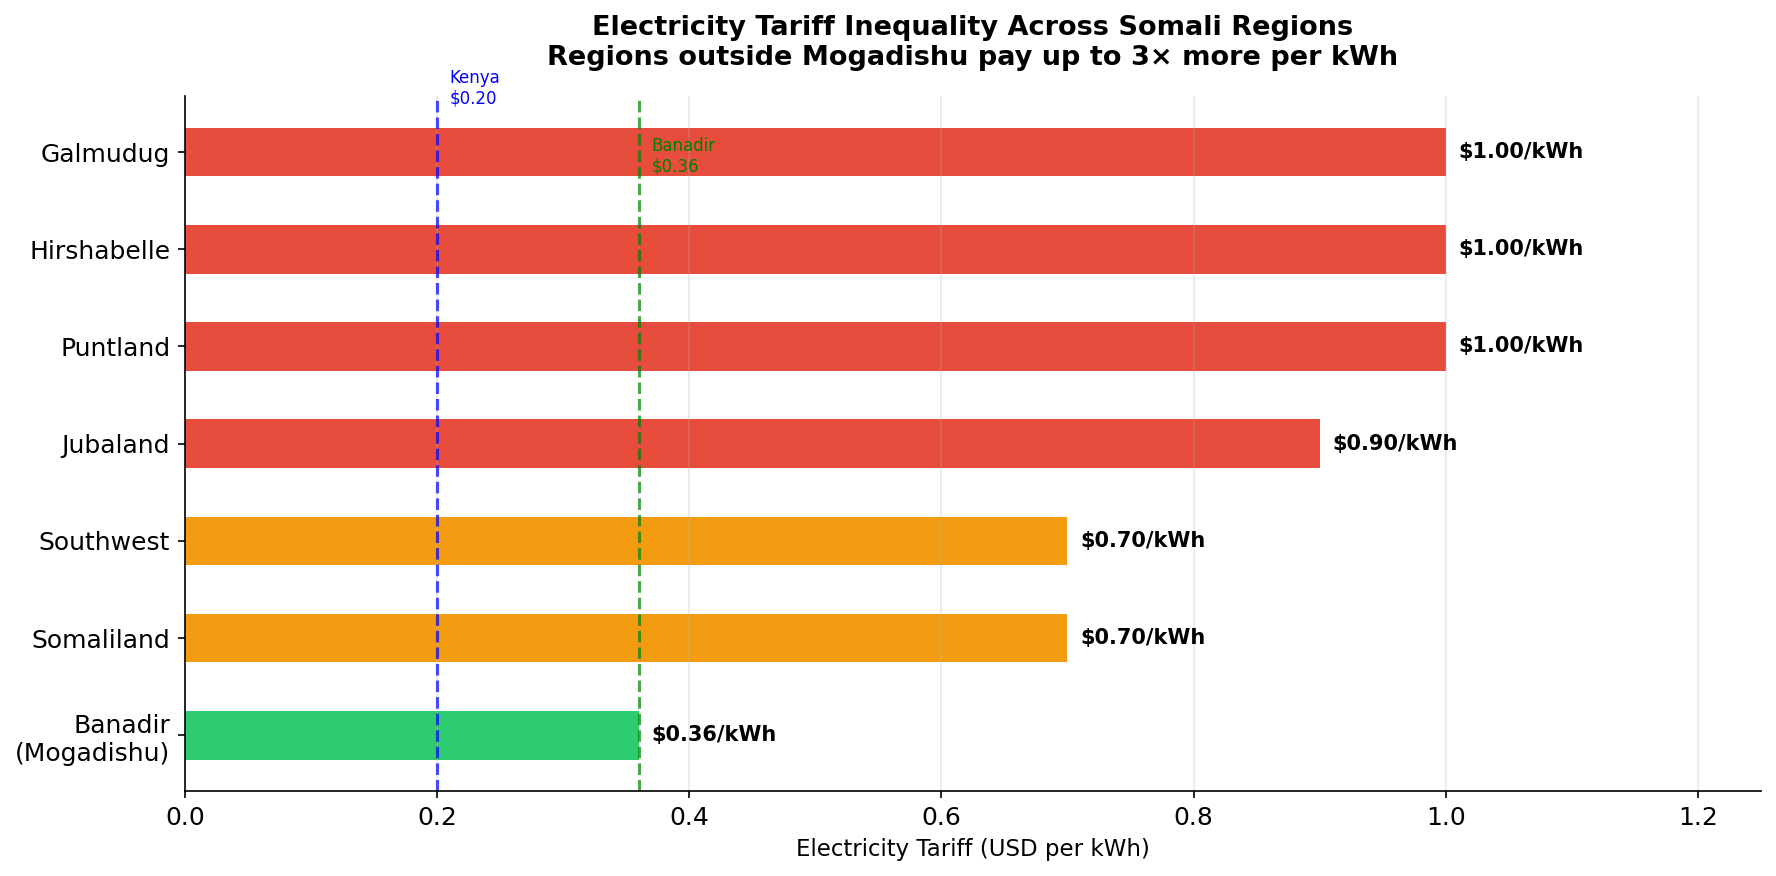

In [7]:
# Figure 4 — Electricity Tariff Inequality Across Regions

regions = ["Banadir\n(Mogadishu)", "Somaliland", "Southwest",
           "Jubaland", "Puntland", "Hirshabelle", "Galmudug"]
tariffs = [0.36, 0.70, 0.70, 0.90, 1.00, 1.00, 1.00]
colors  = ["#2ecc71" if t < 0.5 else "#f39c12" if t < 0.9 else "#e74c3c"
           for t in tariffs]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(regions, tariffs, color=colors, height=0.5)

# Add value labels
for bar, val in zip(bars, tariffs):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"${val:.2f}/kWh", va="center", ha="left",
            fontsize=10, fontweight="bold")

# Add reference lines
ax.axvline(x=0.20, color="blue", linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(0.21, 6.5, "Kenya\n$0.20", fontsize=8, color="blue")

ax.axvline(x=0.36, color="green", linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(0.37, 5.8, "Banadir\n$0.36", fontsize=8, color="green")

ax.set_xlim(0, 1.25)
ax.set_xlabel("Electricity Tariff (USD per kWh)", fontsize=11)
ax.set_title("Electricity Tariff Inequality Across Somali Regions\n"
             "Regions outside Mogadishu pay up to 3× more per kWh",
             fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("figure4_tariff_inequality.jpg", dpi=300, bbox_inches="tight")
plt.show()

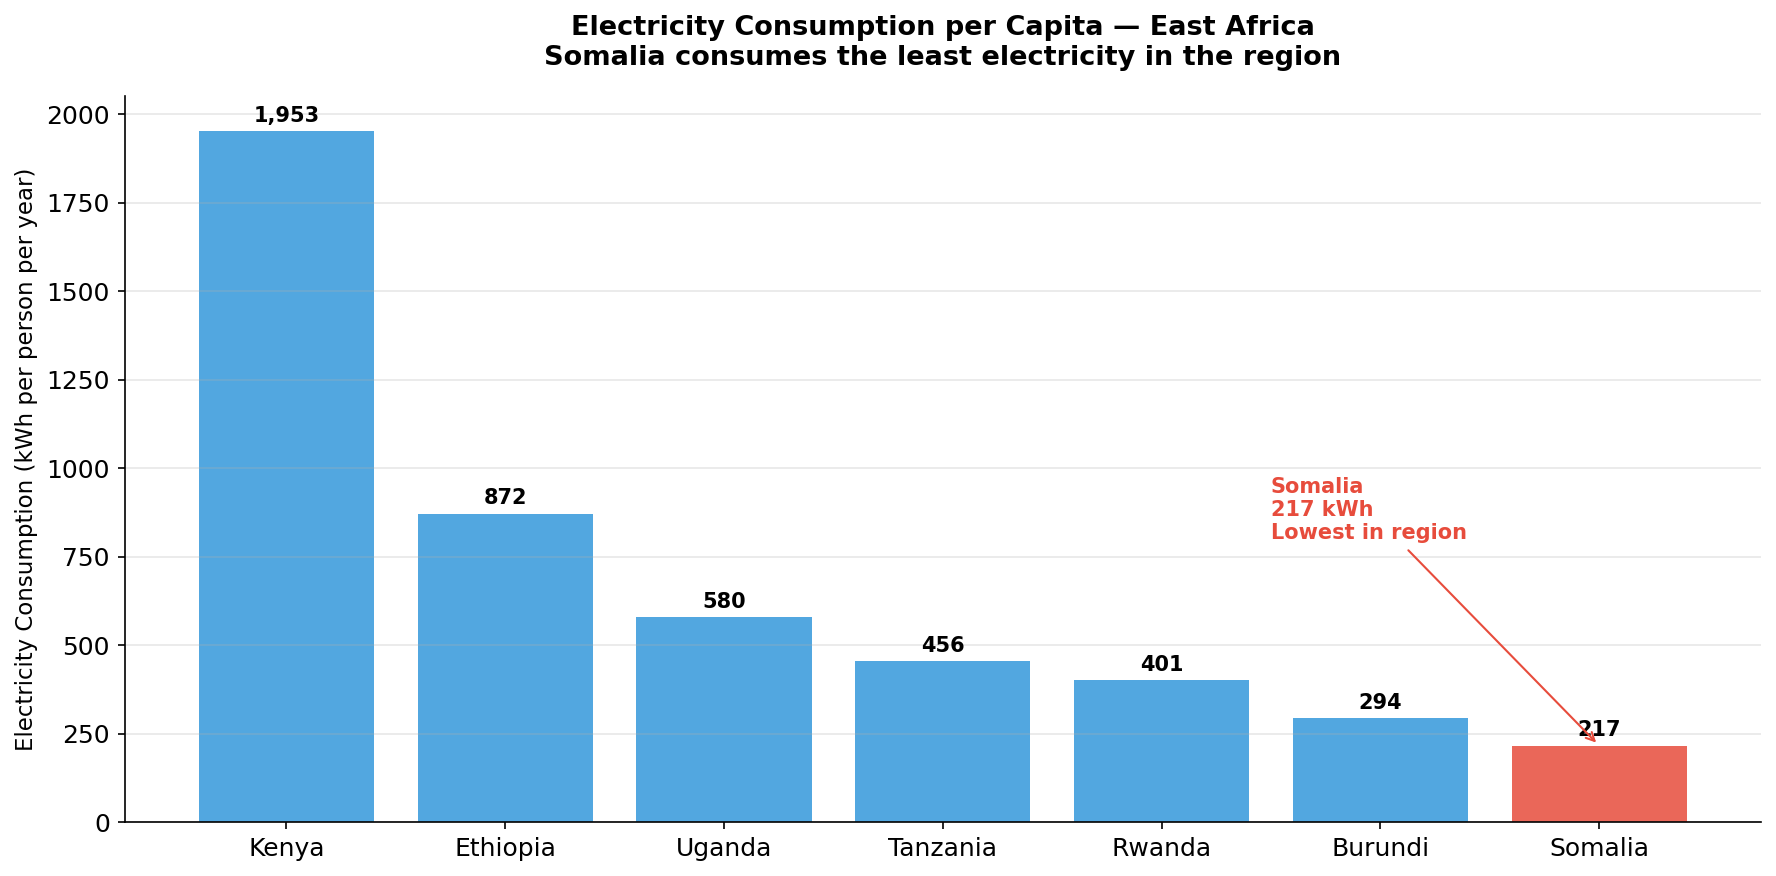

In [8]:
# Figure 5 — East Africa Energy Consumption Comparison

countries = ["Kenya", "Ethiopia", "Uganda", 
             "Tanzania", "Rwanda", "Burundi", "Somalia"]
kwh       = [1953, 872, 580, 456, 401, 294, 217]
colors    = ["#e74c3c" if c == "Somalia" else "#3498db" 
             for c in countries]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(countries, kwh, color=colors, alpha=0.85)

for bar, val in zip(bars, kwh):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 15,
            f"{val:,}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_ylabel("Electricity Consumption (kWh per person per year)", fontsize=11)
ax.set_title("Electricity Consumption per Capita — East Africa\n"
             "Somalia consumes the least electricity in the region",
             fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3, axis="y")

# Highlight Somalia
ax.annotate("Somalia\n217 kWh\nLowest in region",
            xy=(6, 217), xytext=(4.5, 800),
            arrowprops=dict(arrowstyle="->", color="#e74c3c"),
            fontsize=10, color="#e74c3c", fontweight="bold")

plt.tight_layout()
plt.savefig("figure5_energy_comparison.jpg", dpi=300, bbox_inches="tight")
plt.show()

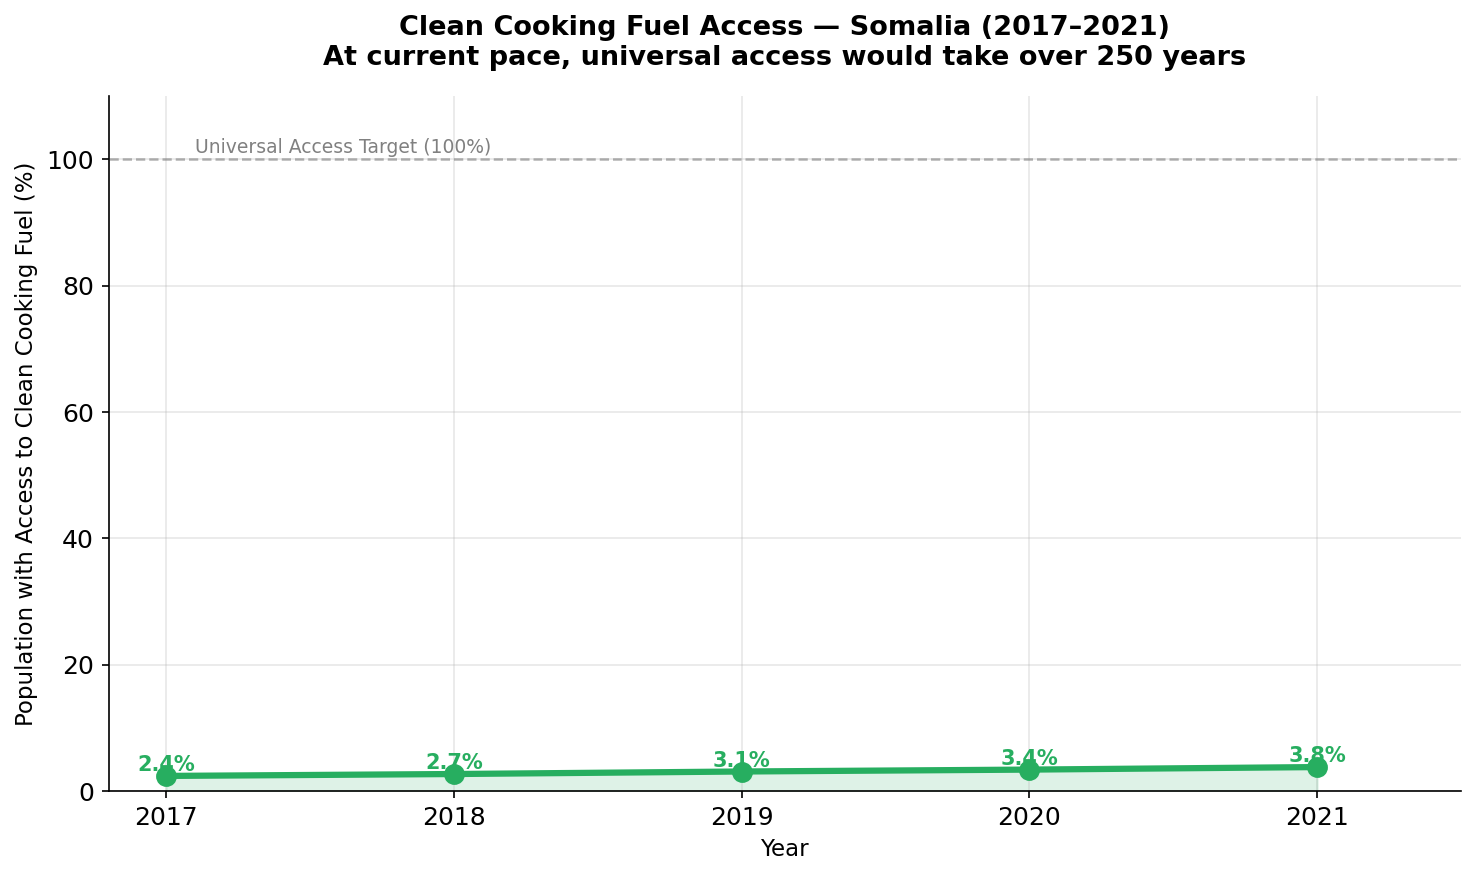

In [9]:
# Figure 6 — Clean Cooking Fuel Access Trend

years  = [2017, 2018, 2019, 2020, 2021]
access = [2.4, 2.7, 3.1, 3.4, 3.8]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(years, access, color="#27ae60", linewidth=3,
        marker="o", markersize=9)
ax.fill_between(years, access, 0,
                alpha=0.15, color="#27ae60")

# Add value labels
for x, y in zip(years, access):
    ax.text(x, y + 0.1, f"{y}%", ha="center",
            va="bottom", fontsize=10, fontweight="bold",
            color="#27ae60")

# Add target line
ax.axhline(y=100, color="gray", linestyle="--",
           linewidth=1.2, alpha=0.6)
ax.text(2017.1, 101, "Universal Access Target (100%)",
        fontsize=9, color="gray")

ax.set_xlim(2016.8, 2021.5)
ax.set_ylim(0, 110)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Population with Access to Clean Cooking Fuel (%)",
              fontsize=11)
ax.set_title("Clean Cooking Fuel Access — Somalia (2017–2021)\n"
             "At current pace, universal access would take over 250 years",
             fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figure6_clean_cooking.jpg", dpi=300, bbox_inches="tight")
plt.show()